# Ddri Station-Day 데이터셋 설명 노트북

이 노트북은 예측용 baseline 데이터셋이 어떤 구조로 만들어졌는지 설명한다.

## 이 노트북의 목적

- target과 grain을 다시 확인한다.
- 운영 보조 지표(self-return, net_flow 등)를 왜 유지했는지 설명한다.
- 캘린더, 날씨, 군집 label이 어떻게 결합됐는지 보여준다.
- 발표와 레포트에 사용할 근거 차트를 정리한다.

## 1. 기본 경로와 데이터셋 로드

현재 baseline 예측 문제는 `station-day` 단위 회귀이며, 1차 target은 `rental_count`다. 이 셀에서는 실제 학습용 데이터셋과 운영 지표 요약 파일을 불러온다.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

BASE_DIR = Path('/Users/cheng80/Desktop/ddri_work')
DATA_DIR = BASE_DIR / 'works' / '03_prediction' / '02_data'
SUPPORT_DATA_DIR = BASE_DIR / 'works' / '03_prediction' / 'support_data'
IMG_DIR = BASE_DIR / 'works' / '03_prediction' / 'support_images'

train_path = DATA_DIR / 'ddri_station_day_train_baseline_dataset.csv'
test_path = DATA_DIR / 'ddri_station_day_test_baseline_dataset.csv'
flow_summary_path = SUPPORT_DATA_DIR / 'ddri_station_day_flow_metrics_summary.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
flow_summary = pd.read_csv(flow_summary_path)

print('train shape:', train_df.shape)
print('test shape:', test_df.shape)

train shape: (114923, 27)
test shape: (56610, 27)


## 2. 컬럼 구조 확인

예측용 baseline은 크게 네 묶음으로 본다.

- target/운영 지표: `rental_count`, `return_count`, `same_station_return_ratio`, `net_flow`
- 캘린더: `day_of_week`, `is_weekend`, `is_holiday`
- 날씨: `temperature_mean`, `humidity_mean`, `precipitation_sum`
- 대여소/군집: `cluster_label`, `대여소명`, `위도`, `경도`

In [2]:
display(train_df.head())
print(train_df.columns.tolist())

,station_id,date,rental_count,return_count,same_station_return_count,same_station_return_ratio,net_flow,year,month,day,...,temperature_min,temperature_max,humidity_mean,wind_speed_mean,precipitation_sum,is_rainy_day,cluster_label,대여소명,위도,경도
0,2301,2023-01-01,1,4,0,0.000000,-3,2023,1,1,...,-5.9,1.8,61.083333,11.208333,0.0,0,1,현대고등학교 건너편,37.524071,127.02179
1,2301,2023-01-02,8,6,0,0.000000,2,2023,1,2,...,-8.7,-2.2,48.000000,10.850000,0.0,0,1,현대고등학교 건너편,37.524071,127.02179
2,2301,2023-01-03,7,3,0,0.000000,4,2023,1,3,...,-9.4,-1.3,47.291667,7.808333,0.0,0,1,현대고등학교 건너편,37.524071,127.02179
3,2301,2023-01-04,13,11,7,0.538462,2,2023,1,4,...,-7.1,1.6,58.666667,5.595833,0.0,0,1,현대고등학교 건너편,37.524071,127.02179
4,2301,2023-01-05,8,6,3,0.375000,2,2023,1,5,...,-6.2,3.2,61.000000,5.054167,0.0,0,1,현대고등학교 건너편,37.524071,127.02179


['station_id', 'date', 'rental_count', 'return_count', 'same_station_return_count', 'same_station_return_ratio', 'net_flow', 'year', 'month', 'day', 'day_of_week', 'is_weekend', 'holiday_name', 'holiday_count', 'is_holiday', 'is_business_holiday', 'temperature_mean', 'temperature_min', 'temperature_max', 'humidity_mean', 'wind_speed_mean', 'precipitation_sum', 'is_rainy_day', 'cluster_label', '대여소명', '위도', '경도']


## 3. 운영 보조 지표 확인

같은 대여소로 다시 반납된 이동은 실제로는 한 번 대여가 발생한 로그이므로 수요에서 빼지 않는다. 대신 재고가 얼마나 바뀌는지 보기 위해 `return_count`, `same_station_return_ratio`, `net_flow`를 별도 지표로 유지한다.

In [3]:
display(flow_summary)
print('학습 self-return 평균 비율:', round(train_df['same_station_return_ratio'].mean(), 4))
print('테스트 self-return 평균 비율:', round(test_df['same_station_return_ratio'].mean(), 4))

,dataset,rows,rental_count_sum,return_count_sum,same_station_return_count_sum,same_station_return_ratio_mean,net_flow_mean
0,train_2023_2024,114923,1860583,1816593,194456,0.092752,0.382778
1,test_2025,56610,825111,802222,88382,0.097062,0.404328


학습 self-return 평균 비율: 0.0928
테스트 self-return 평균 비율: 0.0971


## 4. 근거 차트 확인

운영 지표와 예측 입력 변수는 숫자 표보다 차트로 볼 때 훨씬 직관적이다. 아래 차트는 self-return 유지 판단과 baseline feature 구조 설명에 직접 활용한다.

ddri_flow_metrics_summary.png exists= True


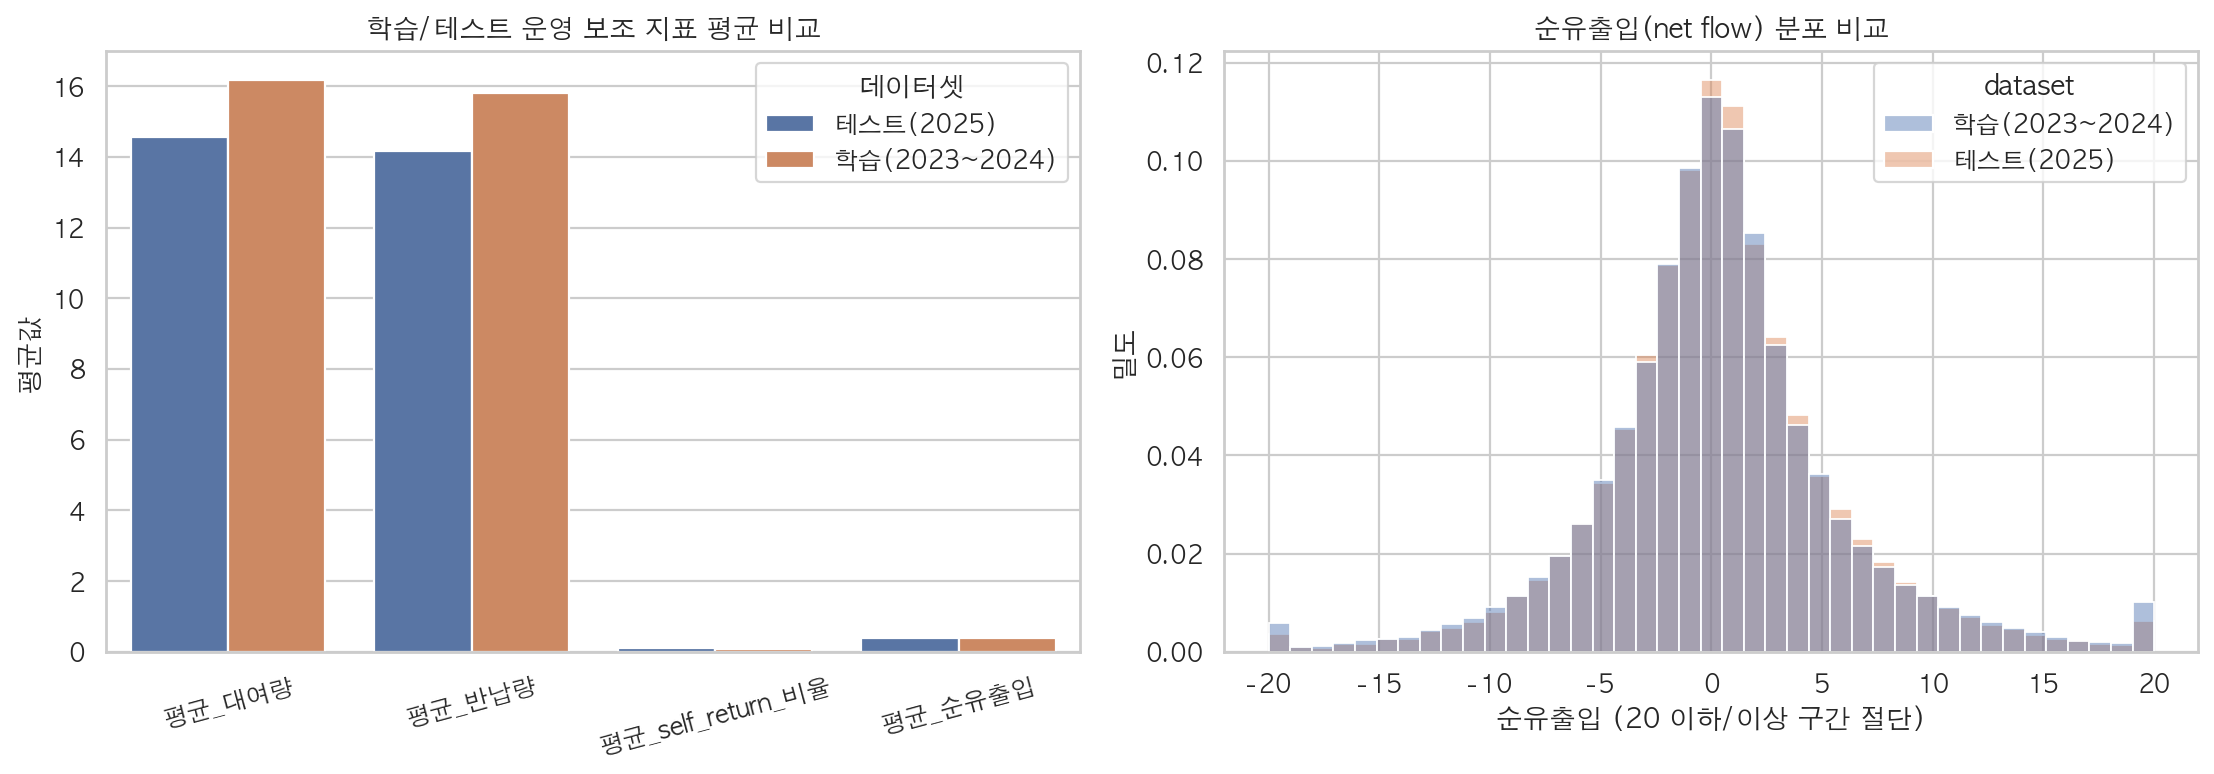

ddri_same_station_return_ratio_boxplot.png exists= True


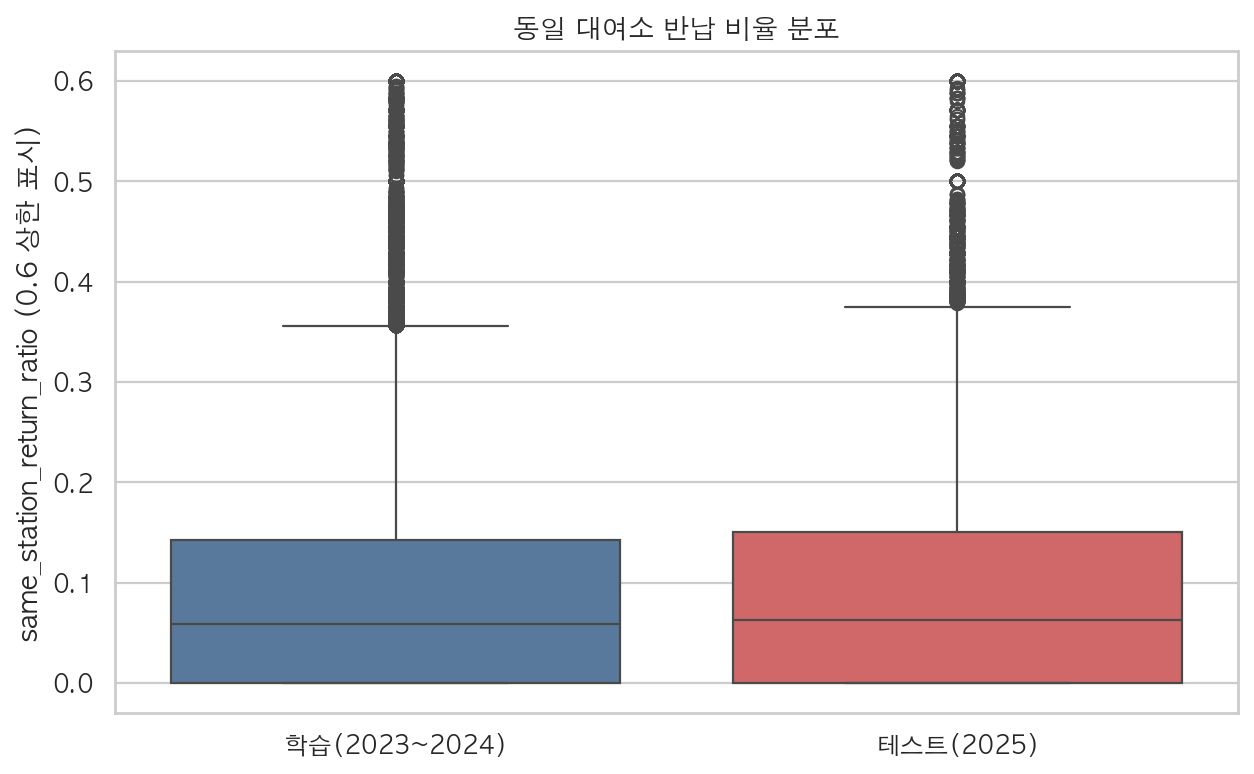

ddri_prediction_feature_correlation_heatmap.png exists= True


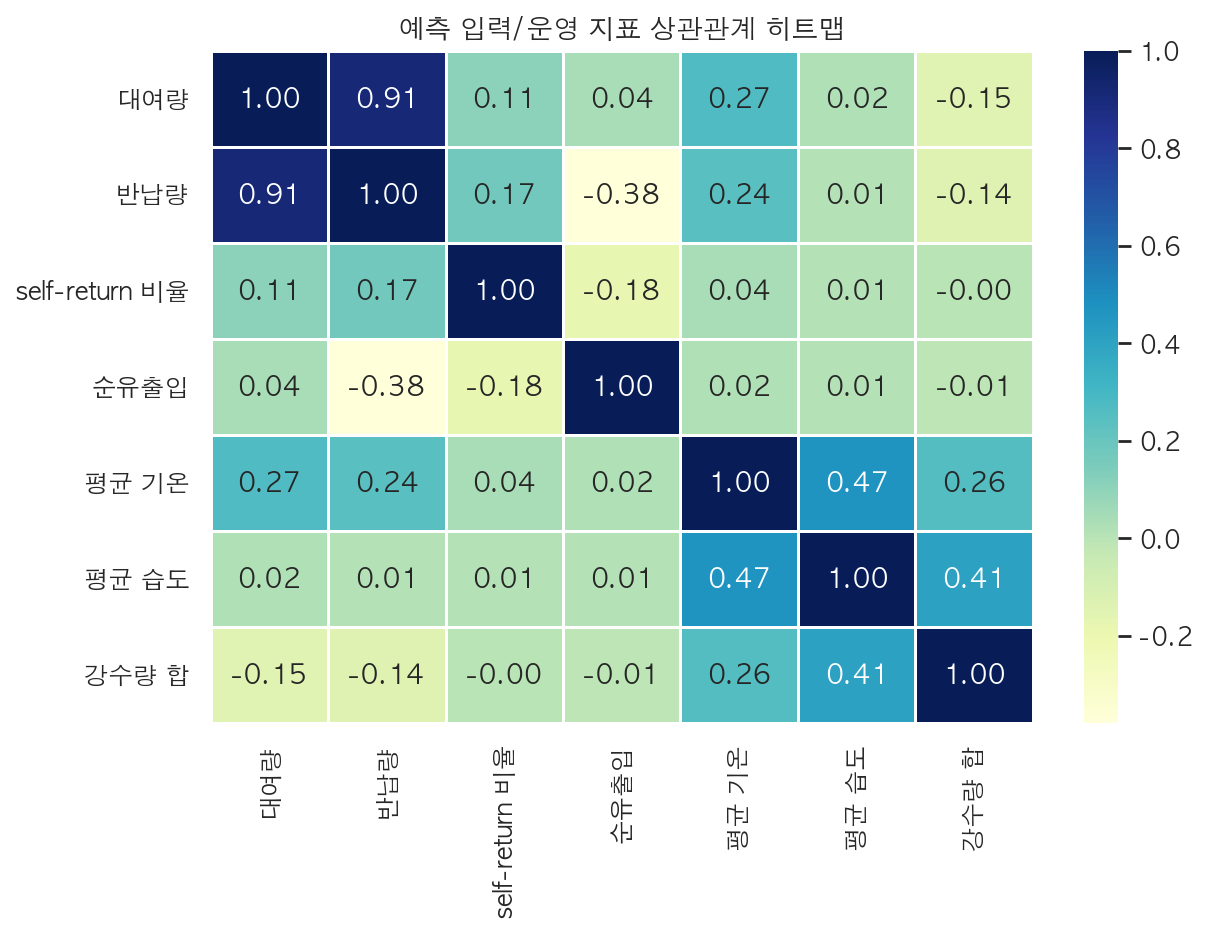

ddri_holiday_weekend_rental_comparison.png exists= True


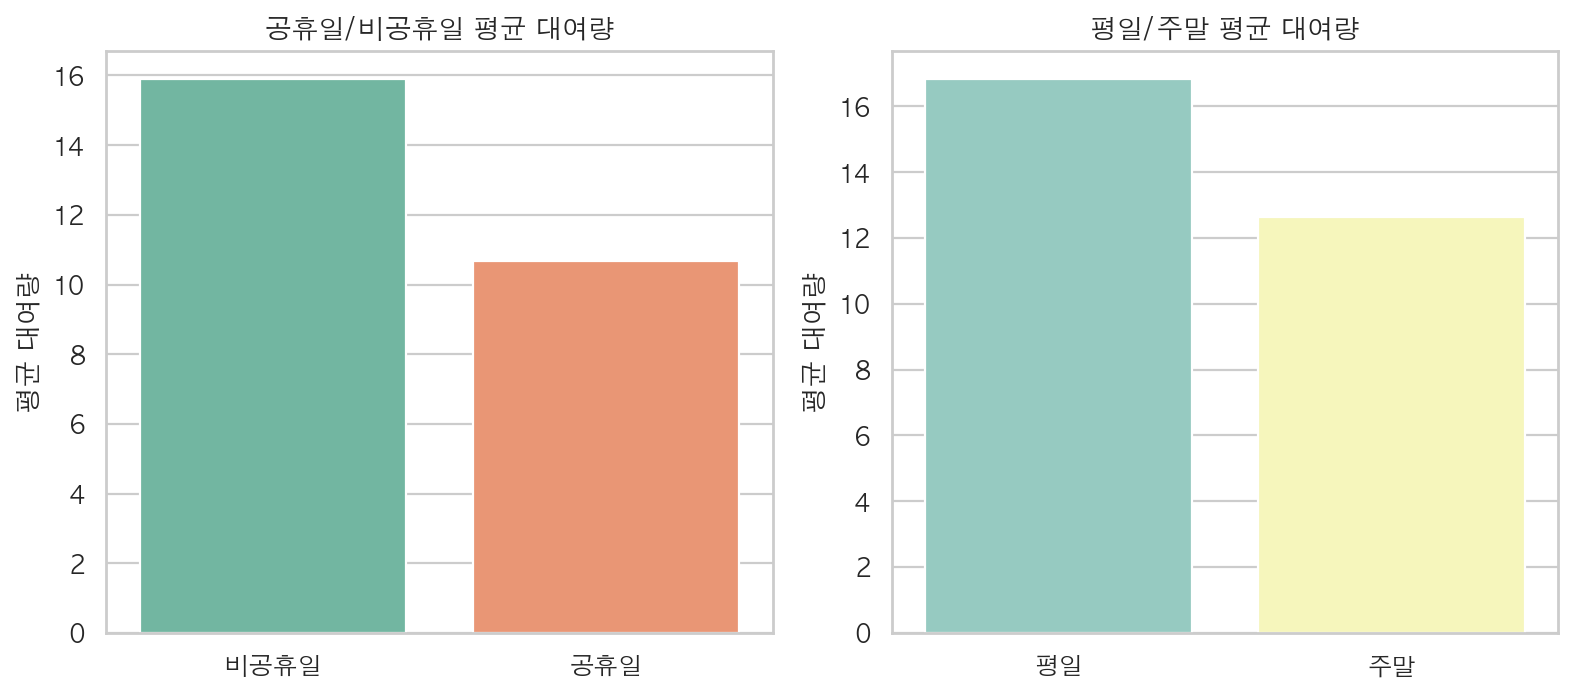

ddri_monthly_avg_rental_trend.png exists= True


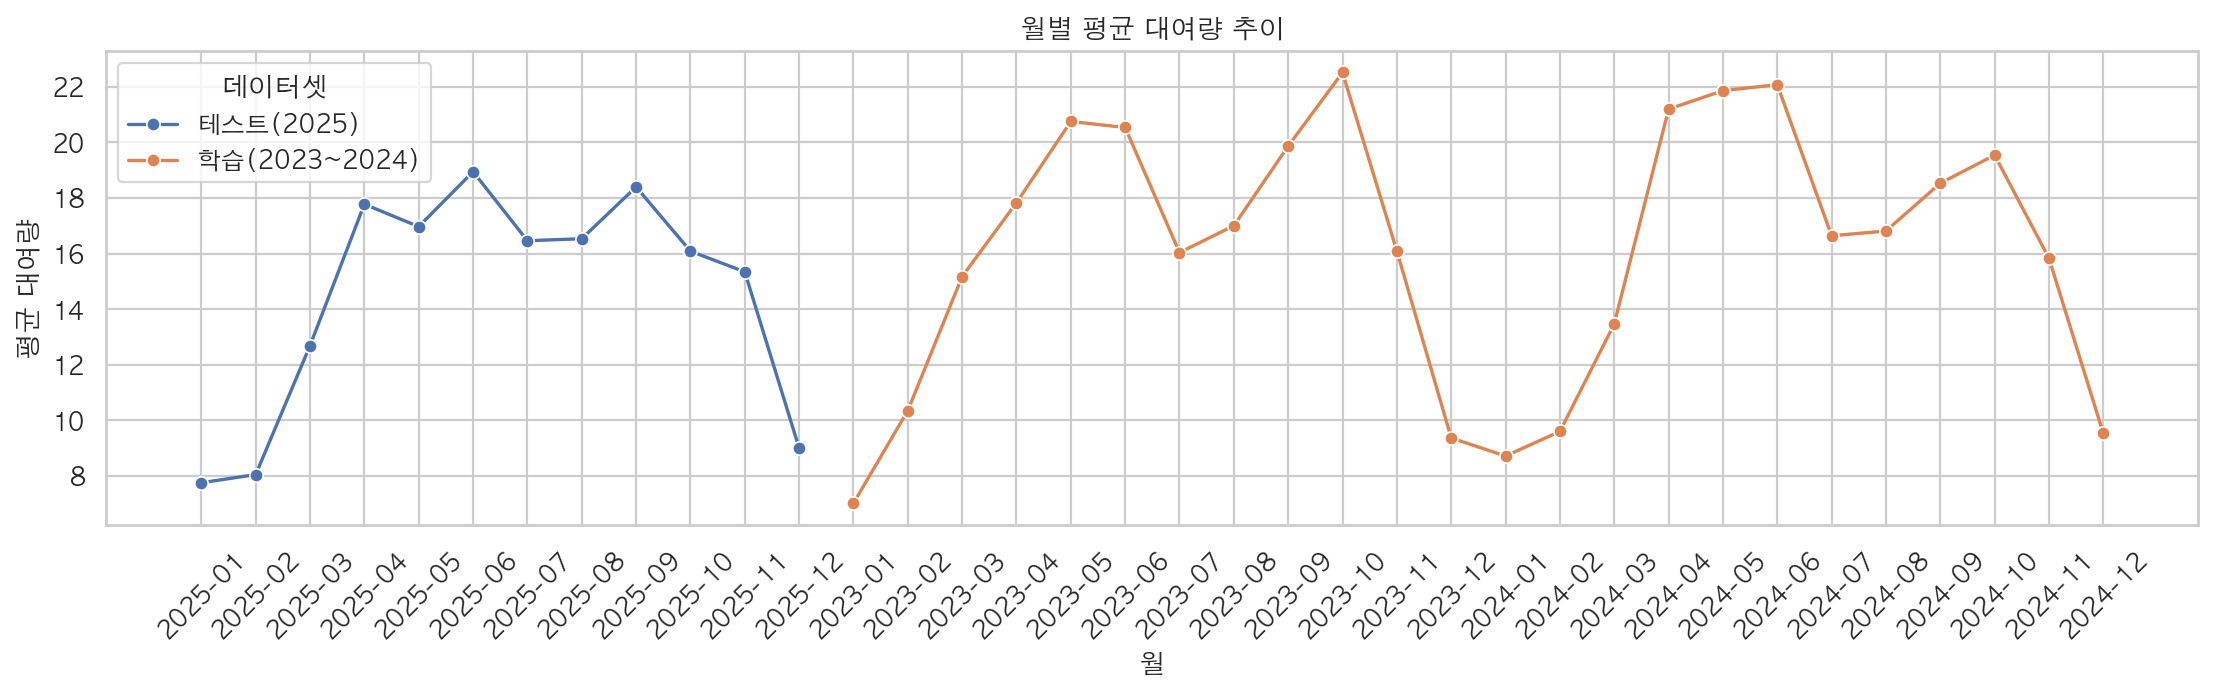

In [4]:
for image_name in [
    'ddri_flow_metrics_summary.png',
    'ddri_same_station_return_ratio_boxplot.png',
    'ddri_prediction_feature_correlation_heatmap.png',
    'ddri_holiday_weekend_rental_comparison.png',
    'ddri_monthly_avg_rental_trend.png',
]:
    image_path = IMG_DIR / image_name
    print(image_name, 'exists=', image_path.exists())
    if image_path.exists():
        display(Image(filename=image_path))

## 5. 이 데이터셋을 어떻게 읽어야 하는가

- `rental_count`는 예측해야 할 값이다.
- `return_count`와 `net_flow`는 적정 보유 대수 해석에 더 직접적인 보조 지표다.
- `same_station_return_ratio`는 self-return을 제거하지 않은 이유를 설명하는 지표다.
- `cluster_label`은 군집화 파트의 결과를 예측 feature로 넘긴 첫 번째 연결 고리다.